In [5]:
import pandas as pd 

nav_history = pd.read_csv("data/raw/02_nav_history.csv")
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [8]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

print(nav_history.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [9]:
nav_history = nav_history.sort_values(by=["amfi_code", "date"]).reset_index(drop=True)
nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [13]:
nav_history["nav"] = nav_history.groupby("amfi_code")["nav"].ffill()

print("missing NAV values : ", nav_history["nav"].isnull().sum())

missing NAV values :  0


In [16]:
nav_history = nav_history[nav_history["nav"] > 0]

print("Invalid NAV values : ", (nav_history["nav"] <= 0).sum())

Invalid NAV values :  0


In [18]:
nav_history.to_csv("data/processed/clean_nav.csv", index=False)

print("clean_nav.csv saved successfully!")

clean_nav.csv saved successfully!


In [21]:
import pandas as pd
import os

transactions = pd.read_csv("data/raw/08_investor_transactions.csv")

print(transactions.head())
print(transactions.columns.tolist())

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

In [22]:
nav_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [28]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [27]:
transactions["transaction_type"] = (transactions["transaction_type"]
                                    .str.strip()
                                    .str.title()
                                    )

valid_types = ["Sip", "Lumpsum", "redemption"]

transactions = transactions[transactions["transaction_type"].isin(valid_types)]

transactions = transactions[transactions["amount_inr"] > 0]

transactions["kyc_status"] = (
    transactions["kyc_status"]
    .str.strip()
    .str.upper()
)

transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"],
                                                  errors="coerce")

transactions = transactions.dropna(subset=["transaction_date"]) 

os.makedirs("data/processes", exist_ok=True)

transactions.to_csv("data/processed/clean_transactions.csv", index=False)

print("clean_transactions.csv saved successfully!")

clean_transactions.csv saved successfully!


In [1]:
import pandas as pd
import numpy as np
import os

performance = pd.read_csv("data/raw/07_scheme_performance.csv")

print(performance.head())
print(performance.columns.tolist())

   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct           20.59           23.14           21.82   
4       Gilt  Regular            5.34            6.07            5.43   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49

In [3]:
print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [3]:
import pandas as pd 
import numpy as np

returns = pd.read_csv("data/processed/returns_computed.csv")

returns.head()

,amfi_code,date,nav,daily_return,annualised_return
0,100016,2022-01-03,520.4608,0.000000,0.025412
1,100016,2022-01-04,515.0971,-0.010306,0.025412
2,100016,2022-01-05,521.7239,0.012865,0.025412
3,100016,2022-01-06,515.7880,-0.011377,0.025412
4,100016,2022-01-07,515.1639,-0.001210,0.025412


In [6]:
performance["return_1yr_pct"] = pd.to_numeric(performance["return_1yr_pct"], errors="coerce")
performance["return_3yr_pct"] = pd.to_numeric(performance["return_3yr_pct"], errors="coerce")
performance["return_5yr_pct"] = pd.to_numeric(performance["return_5yr_pct"], errors="coerce")

performance["negative_sharpe"] = performance["sharpe_ratio"] < 0

performance = performance[
    (performance["expense_ratio_pct"] >= 0.1)&
    (performance["expense_ratio_pct"] <= 2.5)
]

performance = performance.dropna(subset=["return_1yr_pct", "return_3yr_pct", "return_5yr_pct"])

os.makedirs("data/processed", exist_ok=True)
performance.to_csv("data/processed/clean_performance.csv", index=False)

print("clean_performance.csv saved sucessfully!")

clean_performance.csv saved sucessfully!


In [4]:
import pandas as pd
import numpy as np


file_path = "data/processed/returns_computed.csv"

returns = pd.read_csv(file_path)

print("File loaded successfully!")
print("Shape:", returns.shape)
print("\nColumns:")
print(returns.columns.tolist())

File loaded successfully!
Shape: (46000, 5)

Columns:
['amfi_code', 'date', 'nav', 'daily_return', 'annualised_return']


In [5]:
import pandas as pd
import numpy as np

returns.columns = (
    returns.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nCleaned columns:")
print(returns.columns.tolist())


Cleaned columns:
['amfi_code', 'date', 'nav', 'daily_return', 'annualised_return']


In [ ]:
import pandas as pd
import numpy as np

# Possible names for fund and return columns
fund_candidates = [
    "fund_name",
    "scheme_name",
    "fund",
    "scheme",
    "fund_house"
]

return_candidates = [
    "daily_return",
    "return",
    "returns",
    "return_pct",
    "daily_returns"
]

fund_col = next(
    (c for c in fund_candidates if c in returns.columns),
    None
)

return_col = next(
    (c for c in return_candidates if c in returns.columns),
    None
)



In [9]:
returns = pd.read_csv("data/processed/returns_computed.csv")

print(returns.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return', 'annualised_return']


In [ ]:
import pandas as pd
import numpy as np

returns = pd.read_csv(
    "data/processed/returns_computed.csv"
)

returns["daily_return"] = pd.to_numeric(
    returns["daily_return"],
    errors="coerce"
)

returns = returns.dropna(
    subset=["amfi_code", "daily_return"]
)


results = []

for fund_code, group in returns.groupby("amfi_code"):

    daily_returns = group["daily_return"].to_numpy()

    # 95% Historical VaR
    # 5th percentile of daily returns
    var_95 = np.percentile(
        daily_returns,
        5
    )

    
    losses = daily_returns[
        daily_returns <= var_95
    ]

    cvar_95 = np.mean(losses)

    results.append({
        "amfi_code": fund_code,
        "observations": len(daily_returns),
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

# Create report
var_cvar_report = pd.DataFrame(results)

# Round results
var_cvar_report["VaR_95"] = var_cvar_report["VaR_95"].round(6)
var_cvar_report["CVaR_95"] = var_cvar_report["CVaR_95"].round(6)

# Sort by VaR
var_cvar_report = var_cvar_report.sort_values(
    "VaR_95"
).reset_index(drop=True)

# Save
output_path = "data/processed/var_cvar_report.csv"

var_cvar_report.to_csv(
    output_path,
    index=False
)

print("SUCCESS!")
print("Number of funds:", len(var_cvar_report))
print("Saved file:", output_path)

display(var_cvar_report.head(10))

SUCCESS!
Number of funds: 40
Saved file: data/processed/var_cvar_report.csv


,amfi_code,observations,VaR_95,CVaR_95
0,119599,1150,-0.026855,-0.032384
1,119095,1150,-0.026178,-0.031667
2,101207,1150,-0.026020,-0.032459
3,118634,1150,-0.025428,-0.032304
4,119598,1150,-0.024506,-0.030595
5,149324,1150,-0.023476,-0.031036
6,102886,1150,-0.019214,-0.023251
7,100033,1150,-0.019029,-0.023456
8,120505,1150,-0.018888,-0.024342
9,119094,1150,-0.018475,-0.024260


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

returns = pd.read_csv("data/processed/returns_computed.csv")

returns["date"] = pd.to_datetime(returns["date"])

returns.head()

,amfi_code,date,nav,daily_return,annualised_return
0,100016,2022-01-03,520.4608,0.000000,0.025412
1,100016,2022-01-04,515.0971,-0.010306,0.025412
2,100016,2022-01-05,521.7239,0.012865,0.025412
3,100016,2022-01-06,515.7880,-0.011377,0.025412
4,100016,2022-01-07,515.1639,-0.001210,0.025412


In [14]:
five_funds = returns["amfi_code"].dropna().unique()[:5]

print("Selected funds:", five_funds)

Selected funds: [100016 100025 100033 101206 101207]


Selected 5 funds:
[100016, 100025, 100033, 101206, 101207]


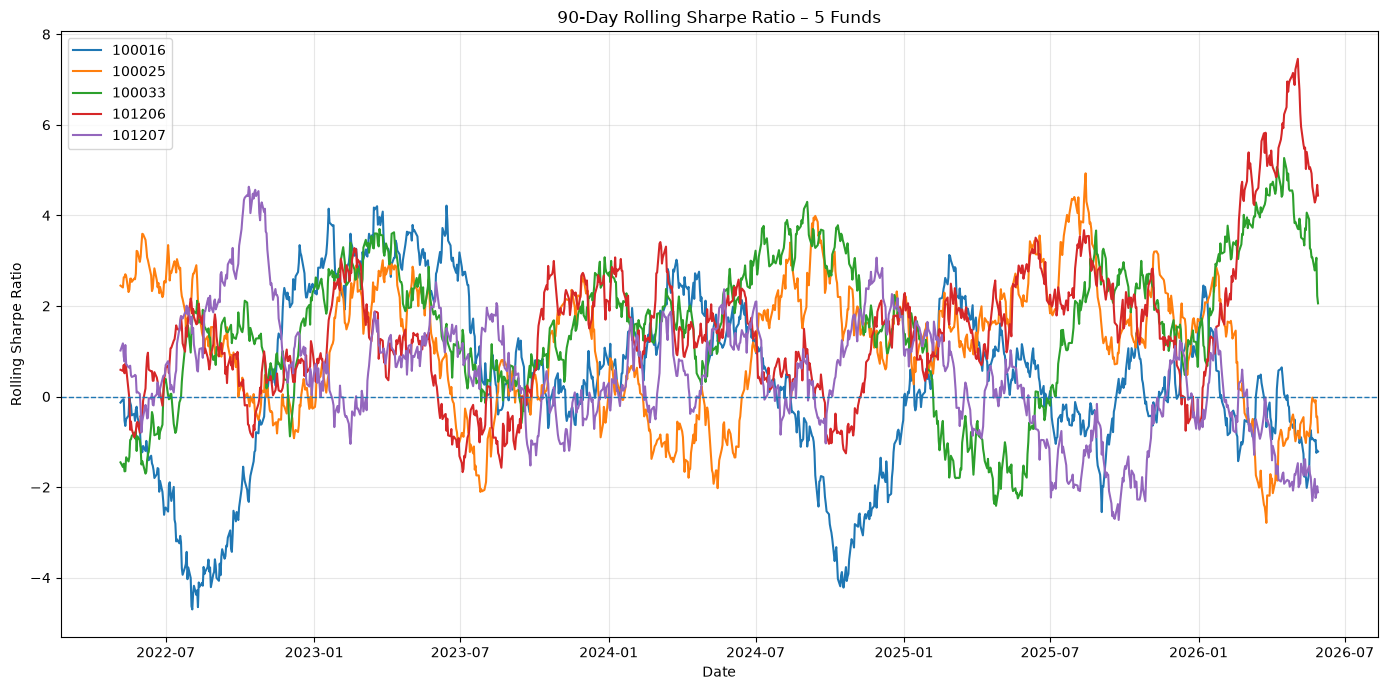


SUCCESS!
Chart saved to:
data/processed/rolling_sharpe_chart.png


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

returns = pd.read_csv(
    "data/processed/returns_computed.csv"
)

returns["date"] = pd.to_datetime(returns["date"])

returns["daily_return"] = pd.to_numeric(
    returns["daily_return"],
    errors="coerce"
)

returns = returns.dropna(
    subset=["amfi_code", "date", "daily_return"]
)

returns = returns.sort_values(
    ["amfi_code", "date"]
)

five_funds = (
    returns["amfi_code"]
    .drop_duplicates()
    .head(5)
    .tolist()
)

print("Selected 5 funds:")
print(five_funds)

rolling_results = []

for fund in five_funds:

    fund_data = returns[
        returns["amfi_code"] == fund
    ].copy()

    fund_data["rolling_sharpe"] = (
        fund_data["daily_return"]
        .rolling(window=90)
        .mean()
        /
        fund_data["daily_return"]
        .rolling(window=90)
        .std()
        * np.sqrt(252)
    )

    rolling_results.append(fund_data)


rolling_sharpe = pd.concat(
    rolling_results,
    ignore_index=True
)

plt.figure(figsize=(14, 7))

for fund in five_funds:

    fund_data = rolling_sharpe[
        rolling_sharpe["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=str(fund)
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "90-Day Rolling Sharpe Ratio – 5 Funds"
)

plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

output_path = (
    "data/processed/rolling_sharpe_chart.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSUCCESS!")
print("Chart saved to:")
print(output_path)

In [19]:
import pandas as pd
import numpy as np
import os

folder = "data/processed"

csv_files = [
    f for f in os.listdir(folder)
    if f.lower().endswith(".csv")
]

print("CSV files found:")
for f in csv_files:
    print(f)

keywords = [
    "transaction",
    "investor",
    "sip",
    "folio"
]

candidate_files = [
    f for f in csv_files
    if any(k in f.lower() for k in keywords)
]

if not candidate_files:
    raise FileNotFoundError(
        "No investor/transaction CSV found in data/processed."
    )

input_file = os.path.join(
    folder,
    candidate_files[0]
)

print("\nUsing file:")
print(input_file)

df = pd.read_csv(input_file)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nColumns:")
print(df.columns.tolist())

def find_column(candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


investor_col = find_column([
    "investor_id",
    "investor",
    "customer_id",
    "client_id",
    "folio_no",
    "folio_number",
    "folio"
])

date_col = find_column([
    "transaction_date",
    "date",
    "txn_date",
    "transactiondate"
])

amount_col = find_column([
    "transaction_amount",
    "amount_inr",
    "txn_amount",
    "invested_amount",
    "sip_amount"
])

transaction_type_col = find_column([
    "transaction_type",
    "transaction_type_name",
    "txn_type",
    "type"
])

fund_col = find_column([
    "scheme_name",
    "fund_name",
    "scheme",
    "fund",
    "amfi_code"
])

print("\nDetected columns:")
print("Investor:", investor_col)
print("Date:", date_col)
print("Amount:", amount_col)
print("Transaction type:", transaction_type_col)
print("Fund:", fund_col)

required = {
    "investor_id": investor_col,
    "date": date_col,
    "amount_inr": amount_col
}

missing = [
    name for name, col in required.items()
    if col is None
]

if missing:
    raise KeyError(
        f"Missing required columns: {missing}. "
        f"Available columns: {df.columns.tolist()}"
    )

df[date_col] = pd.to_datetime(
    df[date_col],
    errors="coerce"
)

df[amount_col] = pd.to_numeric(
    df[amount_col],
    errors="coerce"
)

df = df.dropna(
    subset=[
        investor_col,
        date_col,
        amount_col
    ]
)

first_transaction = (
    df.groupby(investor_col)[date_col]
      .min()
      .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction[date_col]
    .dt.year
)

first_transaction = first_transaction[
    first_transaction["cohort_year"].isin([2024, 2025])
]

df = df.merge(
    first_transaction[
        [investor_col, "cohort_year"]
    ],
    on=investor_col,
    how="inner"
)

if transaction_type_col is not None:

    df["_transaction_type"] = (
        df[transaction_type_col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    sip_df = df[
        df["_transaction_type"]
        .str.contains("sip", na=False)
    ].copy()

else:
    
    sip_df = df.copy()

avg_sip = (
    sip_df.groupby("cohort_year")[amount_col]
    .mean()
    .rename("avg_sip_amount")
)

total_invested = (
    df.groupby("cohort_year")[amount_col]
    .sum()
    .rename("total_invested")
)

investor_count = (
    df.groupby("cohort_year")[investor_col]
    .nunique()
    .rename("investor_count")
)

if fund_col is not None:

    fund_counts = (
        df.groupby(
            ["cohort_year", fund_col]
        )[investor_col]
        .nunique()
        .reset_index(
            name="investor_count"
        )
    )

    preferred_fund = (
        fund_counts
        .sort_values(
            ["cohort_year", "investor_count"],
            ascending=[True, False]
        )
        .drop_duplicates("cohort_year")
        [["cohort_year", fund_col]]
        .rename(
            columns={
                fund_col: "preferred_fund"
            }
        )
        .set_index("cohort_year")
    )

else:

    preferred_fund = pd.DataFrame(
        index=[2024, 2025],
        data={
            "preferred_fund": "Not available"
        }
    )


cohort_analysis = pd.concat(
    [
        investor_count,
        avg_sip,
        total_invested,
        preferred_fund
    ],
    axis=1
).reset_index()


if "avg_sip_amount" in cohort_analysis.columns:
    cohort_analysis["avg_sip_amount"] = (
        cohort_analysis["avg_sip_amount"]
        .round(2)
    )

if "total_invested" in cohort_analysis.columns:
    cohort_analysis["total_invested"] = (
        cohort_analysis["total_invested"]
        .round(2)
    )


output_file = (
    "data/processed/cohort_analysis.csv"
)

cohort_analysis.to_csv(
    output_file,
    index=False
)


print("\n================================")
print("SUCCESS!")
print("================================")

print("\nCohort analysis:")
display(cohort_analysis)

print("\nSaved file:")
print(output_file)

CSV files found:
alpha_beta_values.csv
annualised_returns.csv
cagr_report.csv
clean_nav.csv
clean_performance.csv
clean_transactions.csv
fund_scorecard.csv
max_drawdown.csv
returns_computed.csv
sharpe_values.csv
sortino_values.csv
tracking_error.csv
var_cvar_report.csv

Using file:
data/processed\clean_transactions.csv

Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Detected columns:
Investor: investor_id
Date: transaction_date
Amount: amount_inr
Transaction type: transaction_type
Fund: amfi_code

SUCCESS!

Cohort analysis:


,cohort_year,investor_count,avg_sip_amount,total_invested,preferred_fund
0,2024,4726,11000.69,2250893963,125498
1,2025,217,12593.19,26160976,120507



Saved file:
data/processed/cohort_analysis.csv


In [20]:
import pandas as pd
import numpy as np
import os

folder = "data/processed"

csv_files = [
    f for f in os.listdir(folder)
    if f.lower().endswith(".csv")
]

keywords = [
    "transaction",
    "investor",
    "sip",
    "folio"
]

candidate_files = [
    f for f in csv_files
    if any(k in f.lower() for k in keywords)
]

if not candidate_files:
    raise FileNotFoundError(
        "No transaction/investor CSV found."
    )

input_file = os.path.join(
    folder,
    candidate_files[0]
)

print("Using file:", input_file)



df = pd.read_csv(input_file)


df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Columns:")
print(df.columns.tolist())


def find_column(candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


investor_col = find_column([
    "investor_id",
    "investor",
    "customer_id",
    "client_id",
    "folio_no",
    "folio_number",
    "folio"
])

date_col = find_column([
    "transaction_date",
    "date",
    "txn_date",
    "transactiondate"
])

transaction_type_col = find_column([
    "transaction_type",
    "transaction_type_name",
    "txn_type",
    "type"
])

print("\nDetected columns:")
print("Investor:", investor_col)
print("Date:", date_col)
print("Transaction type:", transaction_type_col)

# --------------------------------------------------
# 4. Validate required columns
# --------------------------------------------------
if investor_col is None:
    raise KeyError(
        "Investor column not found. "
        f"Available columns: {df.columns.tolist()}"
    )

if date_col is None:
    raise KeyError(
        "Date column not found. "
        f"Available columns: {df.columns.tolist()}"
    )

if transaction_type_col is None:
    raise KeyError(
        "Transaction type column not found. "
        f"Available columns: {df.columns.tolist()}"
    )

df[date_col] = pd.to_datetime(
    df[date_col],
    errors="coerce"
)

df = df.dropna(
    subset=[
        investor_col,
        date_col
    ]
)

df["_transaction_type"] = (
    df[transaction_type_col]
    .astype(str)
    .str.strip()
    .str.lower()
)

sip = df[
    df["_transaction_type"]
    .str.contains("sip", na=False)
].copy()

print("\nTotal SIP transactions:", len(sip))


sip = sip.sort_values(
    [investor_col, date_col]
)

sip_counts = (
    sip.groupby(investor_col)
    .size()
    .rename("sip_transactions")
)

eligible_investors = sip_counts[
    sip_counts >= 6
].index

sip = sip[
    sip[investor_col]
    .isin(eligible_investors)
].copy()

print(
    "Investors with 6+ SIP transactions:",
    len(eligible_investors)
)

sip["gap_days"] = (
    sip.groupby(investor_col)[date_col]
    .diff()
    .dt.days
)

continuity = (
    sip.groupby(investor_col)
    .agg(
        sip_transactions=(
            date_col,
            "count"
        ),
        average_gap_days=(
            "gap_days",
            "mean"
        ),
        maximum_gap_days=(
            "gap_days",
            "max"
        )
    )
    .reset_index()
)

continuity["status"] = np.where(
    continuity["average_gap_days"] > 35,
    "at-risk",
    "regular"
)

continuity["average_gap_days"] = (
    continuity["average_gap_days"]
    .round(2)
)

continuity["maximum_gap_days"] = (
    continuity["maximum_gap_days"]
    .round(2)
)

output_file = (
    "data/processed/sip_continuity.csv"
)

continuity.to_csv(
    output_file,
    index=False
)

print("\n================================")
print("SUCCESS!")
print("================================")

print(
    "Investors analysed:",
    len(continuity)
)

print(
    "At-risk investors:",
    (continuity["status"] == "at-risk").sum()
)

print(
    "Regular investors:",
    (continuity["status"] == "regular").sum()
)

print("\nResults:")
display(continuity.head(10))

print("\nSaved file:")
print(output_file)

Using file: data/processed\clean_transactions.csv
Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Detected columns:
Investor: investor_id
Date: transaction_date
Transaction type: transaction_type

Total SIP transactions: 19716
Investors with 6+ SIP transactions: 1362

SUCCESS!
Investors analysed: 1362
At-risk investors: 1332
Regular investors: 30

Results:


,investor_id,sip_transactions,average_gap_days,maximum_gap_days,status
0,INV000004,6,85.40,265.0,at-risk
1,INV000008,6,70.40,165.0,at-risk
2,INV000010,6,64.80,139.0,at-risk
3,INV000011,7,40.17,125.0,at-risk
4,INV000012,8,57.00,132.0,at-risk
5,INV000013,7,55.33,104.0,at-risk
6,INV000014,7,75.33,128.0,at-risk
7,INV000023,8,58.57,115.0,at-risk
8,INV000028,6,93.60,238.0,at-risk
9,INV000029,7,60.67,96.0,at-risk



Saved file:
data/processed/sip_continuity.csv


In [24]:
import pandas as pd

def recommend_funds(risk_appetite, file_path="data/processed/fund_scorecard.csv"):

    funds = pd.read_csv(file_path)

    funds.columns = (
        funds.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    risk_appetite = risk_appetite.strip().lower()

    risk_mapping = {
        "low": "low",
        "moderate": "moderate",
        "high": "high"
    }

    if risk_appetite not in risk_mapping:
        print("Invalid risk appetite.")
        print("Please choose: Low, Moderate, or High.")
        return

    selected_risk = risk_mapping[risk_appetite]

    required_columns = [
        "risk_grade",
        "sharpe"
    ]

    missing = [
        col for col in required_columns
        if col not in funds.columns
    ]

    if missing:
        print("Missing columns:", missing)
        print("Available columns:", funds.columns.tolist())
        return

    funds["sharpe"] = pd.to_numeric(
        funds["sharpe"],
        errors="coerce"
    )

    funds = funds.dropna(
        subset=["sharpe", "risk_grade"]
    )

    funds["risk_grade"] = (
        funds["risk_grade"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    matching_funds = funds[
        funds["risk_grade"] == selected_risk
    ].copy()

    top_funds = (
        matching_funds
        .sort_values(
            "sharpe",
            ascending=False
        )
        .head(3)
    )

    print("\n======================================")
    print("FUND RECOMMENDATION")
    print("======================================")

    print(
        "Risk Appetite:",
        risk_appetite.title()
    )

    print(
        "Matching Risk Grade:",
        selected_risk.title()
    )

    if top_funds.empty:
        print(
            "\nNo funds found for this risk grade."
        )
        return

    print("\nTop 3 Recommended Funds:")

    display_columns = []

    for col in [
        "fund_name",
        "scheme_name",
        "amfi_code",
        "risk_grade",
        "sharpe"
    ]:
        if col in top_funds.columns:
            display_columns.append(col)

    print(
        top_funds[display_columns].to_string(
            index=False
        )
    )

    return top_funds

risk = input(
    "Enter investor risk appetite "
    "(Low/Moderate/High): "
)

recommendations = recommend_funds(risk)

Missing columns: ['risk_grade', 'sharpe']
Available columns: ['amfi_code', 'cagr', 'sharpe_ratio', 'alpha', 'expense_ratio_pct', 'max_drawdown', 'return_rank', 'sharpe_rank', 'alpha_rank', 'expense_rank', 'drawdown_rank', 'fund_score']


In [25]:
from pathlib import Path

code = r'''
import pandas as pd


def recommend_funds(
    risk_appetite,
    file_path="data/processed/fund_scorecard.csv"
):
    """
    Recommend the top 3 funds by Sharpe ratio
    matching the investor's risk appetite.
    """

    funds = pd.read_csv(file_path)

    funds.columns = (
        funds.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    risk_appetite = risk_appetite.strip().lower()

    valid_risks = ["low", "moderate", "high"]

    if risk_appetite not in valid_risks:
        print("Invalid risk appetite.")
        print("Choose: Low, Moderate, or High.")
        return pd.DataFrame()

    required = ["risk_grade", "sharpe"]

    missing = [
        col for col in required
        if col not in funds.columns
    ]

    if missing:
        print("Missing columns:", missing)
        print("Available columns:")
        print(funds.columns.tolist())
        return pd.DataFrame()

    funds["risk_grade"] = (
        funds["risk_grade"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    funds["sharpe"] = pd.to_numeric(
        funds["sharpe"],
        errors="coerce"
    )

    funds = funds.dropna(
        subset=["risk_grade", "sharpe"]
    )

    matching = funds[
        funds["risk_grade"] == risk_appetite
    ].copy()

    recommendations = (
        matching
        .sort_values(
            "sharpe",
            ascending=False
        )
        .head(3)
    )

    print("\n======================================")
    print("FUND RECOMMENDATION")
    print("======================================")
    print("Risk Appetite:", risk_appetite.title())

    if recommendations.empty:
        print("\nNo matching funds found.")
        return recommendations


    display_columns = []

    for column in [
        "fund_name",
        "scheme_name",
        "amfi_code",
        "risk_grade",
        "sharpe"
    ]:
        if column in recommendations.columns:
            display_columns.append(column)

    print("\nTop 3 Recommended Funds:\n")

    print(
        recommendations[
            display_columns
        ].to_string(index=False)
    )

    return recommendations


if __name__ == "__main__":

    risk = input(
        "Enter investor risk appetite "
        "(Low/Moderate/High): "
    )

    recommend_funds(risk)
'''

output_folder = Path("data/processed")
output_folder.mkdir(parents=True, exist_ok=True)

output_file = output_folder / "recommender.py"

with open(output_file, "w", encoding="utf-8") as f:
    f.write(code)

print("SUCCESS!")
print("Created:")
print(output_file)

SUCCESS!
Created:
data\processed\recommender.py


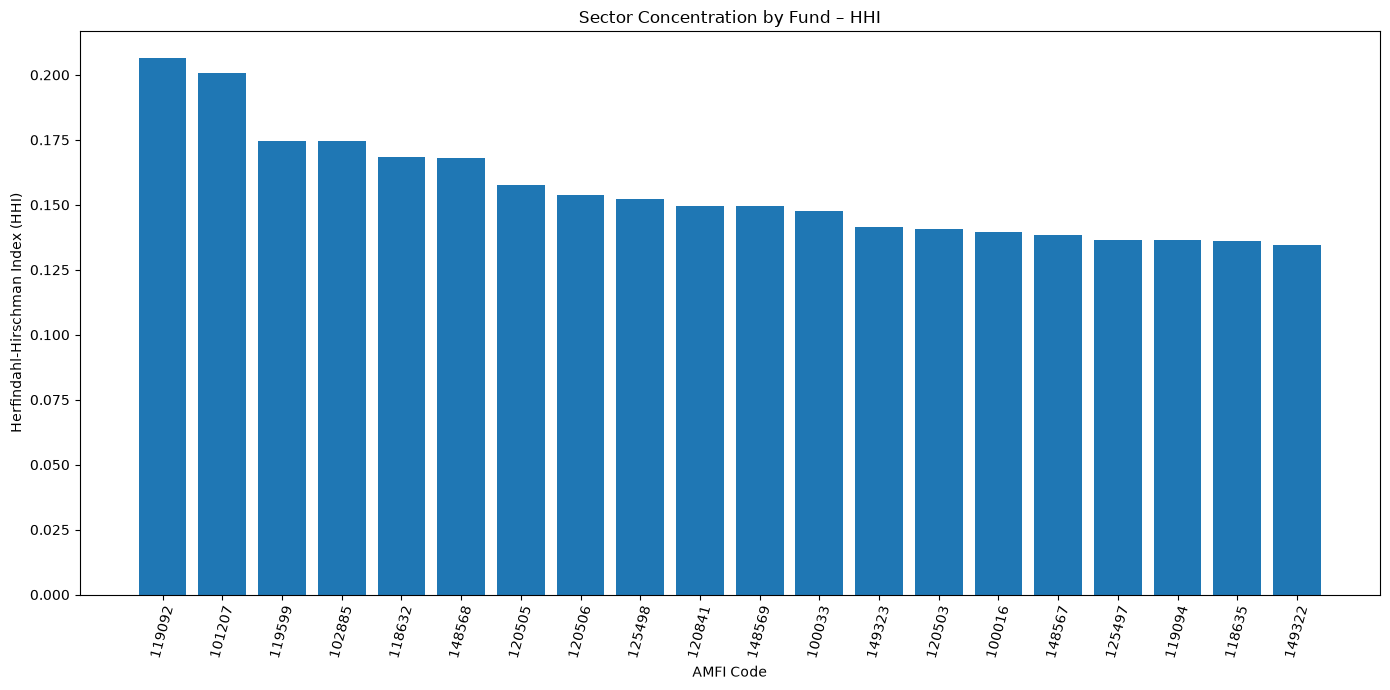

SUCCESS!

CSV saved:
data/processed/sector_hhi.csv

Chart saved:
data/processed/sector_hhi_chart.png

HHI Results:


,amfi_code,HHI,concentration
0,119092,0.206448,Moderate
1,101207,0.200700,Moderate
2,119599,0.174751,Moderate
3,102885,0.174709,Moderate
4,118632,0.168298,Moderate
5,148568,0.167930,Moderate
6,120505,0.157570,Moderate
7,120506,0.153794,Moderate
8,125498,0.152414,Moderate
9,120841,0.149680,Low


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


holdings = pd.read_csv(
    "data/raw/09_portfolio_holdings.csv"
)

holdings.columns = (
    holdings.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

holdings = holdings[
    ["amfi_code", "sector", "weight_pct"]
].copy()

holdings["weight_pct"] = pd.to_numeric(
    holdings["weight_pct"],
    errors="coerce"
)

holdings = holdings.dropna(
    subset=[
        "amfi_code",
        "sector",
        "weight_pct"
    ]
)

holdings["weight"] = (
    holdings["weight_pct"] / 100
)

holdings["weight_squared"] = (
    holdings["weight"] ** 2
)

hhi_report = (
    holdings
    .groupby("amfi_code")["weight_squared"]
    .sum()
    .reset_index()
)

hhi_report = hhi_report.rename(
    columns={
        "weight_squared": "HHI"
    }
)

hhi_report["concentration"] = np.where(
    hhi_report["HHI"] >= 0.25,
    "High",
    np.where(
        hhi_report["HHI"] >= 0.15,
        "Moderate",
        "Low"
    )
)

hhi_report = (
    hhi_report
    .sort_values(
        "HHI",
        ascending=False
    )
    .reset_index(drop=True)
)


hhi_report["HHI"] = (
    hhi_report["HHI"].round(6)
)

csv_output = (
    "data/processed/sector_hhi.csv"
)

hhi_report.to_csv(
    csv_output,
    index=False
)

plt.figure(figsize=(14, 7))

top_funds = hhi_report.head(20)

plt.bar(
    top_funds["amfi_code"].astype(str),
    top_funds["HHI"]
)

plt.title(
    "Sector Concentration by Fund – HHI"
)

plt.xlabel("AMFI Code")
plt.ylabel("Herfindahl-Hirschman Index (HHI)")

plt.xticks(
    rotation=75
)

plt.tight_layout()

chart_output = (
    "data/processed/sector_hhi_chart.png"
)

plt.savefig(
    chart_output,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("====================================")
print("SUCCESS!")
print("====================================")

print("\nCSV saved:")
print(csv_output)

print("\nChart saved:")
print(chart_output)

print("\nHHI Results:")
display(hhi_report.head(10))